# CatBoost

CatBoost is a gradient boosting library built for datasets with categorical features. It handles them natively — no manual encoding, no target-encoding leakage — via a technique called *ordered target statistics*. This makes it a natural fit for the Car Evaluation dataset, where all six features are categorical and previous work spent significant effort encoding them for models that only accept numbers.

Why CatBoost specifically:

- **Native categorical support** — feed raw strings, specify `cat_features=[...]`, done.
- **Built-in imbalance handling** — `auto_class_weights='Balanced'` replaces the need for SMOTE-style resampling.
- **Ordered boosting** — internal defence against overfitting on small datasets (~1400 training rows here).
- **Industry standard on tabular data** — CatBoost, XGBoost, and LightGBM together dominate Kaggle tabular competitions.

The plan: train a baseline with defaults, verify the result with cross-validation, then tune three hyperparameters (`depth`, `learning_rate`, `l2_leaf_reg`) via a manual grid search over 5-fold CV.

Setup and imports.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

from catboost import CatBoostClassifier

RANDOM_STATE = 42
CAT_FEATURES = ['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety']

Load the dataset and produce a stratified 80/20 split. Features stay as raw strings — CatBoost handles the encoding internally.

In [2]:
df = pd.read_csv('dataset/cars_classification_dataset.csv')

X = df.drop('car', axis=1)
y = df['car']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

print(f'Train size: {len(X_train)} | Test size: {len(X_test)}')
print('\nClass distribution in y_train:')
print(y_train.value_counts())

Train size: 1382 | Test size: 346

Class distribution in y_train:
car
unacc    968
acc      307
good      55
vgood     52
Name: count, dtype: int64


### Strategy 1 — Baseline (default hyperparameters)

Train CatBoost with defaults (`iterations=1000`, `depth=6`, learning-rate auto). Only `cat_features` is passed. This shows what CatBoost achieves out of the box.

In [3]:
baseline_pipeline = Pipeline([
    ('clf', CatBoostClassifier(
        cat_features=CAT_FEATURES,
        random_state=RANDOM_STATE,
        verbose=0,
    )),
])

baseline_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](4,)","['acc','good','unacc','vgood']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,6


Per-class metrics and confusion matrix on the held-out test set.

              precision    recall  f1-score   support

         acc      1.000     1.000     1.000        77
        good      1.000     1.000     1.000        14
       unacc      1.000     1.000     1.000       242
       vgood      1.000     1.000     1.000        13

    accuracy                          1.000       346
   macro avg      1.000     1.000     1.000       346
weighted avg      1.000     1.000     1.000       346



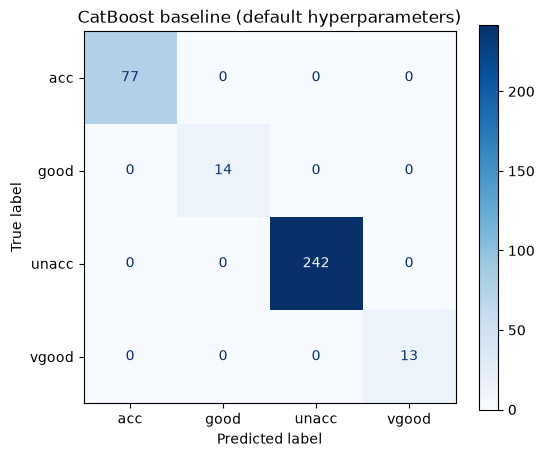

In [4]:
y_pred_baseline = baseline_pipeline.predict(X_test)

print(classification_report(y_test, y_pred_baseline, digits=3))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_baseline,
    labels=baseline_pipeline.classes_,
    cmap='Blues',
    ax=ax,
)
ax.set_title('CatBoost baseline (default hyperparameters)')
plt.show()

### Sanity check — is the dataset deterministic?

The perfect score above is suspicious. Verify it structurally: count unique feature combinations, and check whether any combination maps to more than one target label. If every combination has exactly one label, the target is a deterministic function of the features — meaning perfect scores are achievable in principle, not necessarily a sign of overfitting.

In [5]:
n_combos = len(df.groupby(list(X.columns)))
max_labels_per_combo = df.groupby(list(X.columns))['car'].nunique().max()

print(f'Rows in dataset:              {len(df)}')
print(f'Unique feature combinations:  {n_combos}')
print(f'Max distinct labels per combo: {max_labels_per_combo}')

Rows in dataset:              1728
Unique feature combinations:  1728
Max distinct labels per combo: 1


### Confirming the score with cross-validation

A single 80/20 split can be lucky. Rerun with 5-fold stratified CV — if the mean is close to 1.0 with low variance, the perfect score generalises. If the CV mean drops significantly, our test split was simply on the "easy" side.

`GridSearchCV` and `cross_val_score` do not play well with CatBoost (its constructor mutates `cat_features`, breaking sklearn's `clone` contract), so a manual CV loop is used instead.

In [7]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
fold_scores = []

for fold_idx, (train_idx, test_idx) in enumerate(cv.split(X, y), start=1):
    X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
    y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]

    fold_model = CatBoostClassifier(
        cat_features=CAT_FEATURES,
        random_state=RANDOM_STATE,
        verbose=0,
    )
    fold_model.fit(X_tr, y_tr)
    y_pred_fold = fold_model.predict(X_te)
    fold_score = f1_score(y_te, y_pred_fold, average='macro')
    fold_scores.append(fold_score)
    print(f'Fold {fold_idx}: macro F1 = {fold_score:.4f}')

fold_scores = np.array(fold_scores)
print(f'\nMean: {fold_scores.mean():.4f} | Std: {fold_scores.std():.4f}')

Fold 1: macro F1 = 0.9530
Fold 2: macro F1 = 0.9782
Fold 3: macro F1 = 0.9652
Fold 4: macro F1 = 0.9679
Fold 5: macro F1 = 0.9453

Mean: 0.9619 | Std: 0.0116


### Strategy 2 — Grid-search tuning

Manual grid search over three CatBoost hyperparameters, evaluated with 5-fold CV per candidate. Each candidate gets a mean macro F1 over the folds; the best combination wins.

- `depth`: [4, 6, 8]
- `learning_rate`: [0.03, 0.1]
- `l2_leaf_reg`: [1, 5]

Total: 12 candidates × 5 folds = 60 model fits.

In [ ]:
from itertools import product

param_grid = {
    'depth': [4, 6, 8],
    'learning_rate': [0.03, 0.1],
    'l2_leaf_reg': [1, 5],
}

keys = list(param_grid.keys())
combinations = list(product(*[param_grid[k] for k in keys]))
print(f'Searching {len(combinations)} combinations x 5 folds = {len(combinations) * 5} fits\n')

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
results = []

for combo_idx, combo in enumerate(combinations, start=1):
    params = dict(zip(keys, combo))
    fold_scores = []

    for train_idx, test_idx in cv.split(X, y):
        X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
        y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]

        model = CatBoostClassifier(
            cat_features=CAT_FEATURES,
            random_state=RANDOM_STATE,
            verbose=0,
            **params,
        )
        model.fit(X_tr, y_tr)
        y_pred_fold = model.predict(X_te)
        fold_scores.append(f1_score(y_te, y_pred_fold, average='macro'))

    mean_score = float(np.mean(fold_scores))
    std_score = float(np.std(fold_scores))
    results.append({**params, 'mean_macro_f1': mean_score, 'std': std_score})
    print(f'[{combo_idx:2d}/{len(combinations)}] {params} -> mean F1 = {mean_score:.4f} (std {std_score:.4f})')

results_df = pd.DataFrame(results).sort_values('mean_macro_f1', ascending=False).reset_index(drop=True)
print('\nTop 5:')
results_df.head()

Retrain a fresh model on the full training set using the winning hyperparameters, then evaluate on the held-out test set for direct comparison with the baseline.

Best hyperparameters: {'depth': 8, 'learning_rate': 0.03, 'l2_leaf_reg': 1}
CV mean macro F1:     0.9667

              precision    recall  f1-score   support

         acc      1.000     1.000     1.000        77
        good      1.000     1.000     1.000        14
       unacc      1.000     1.000     1.000       242
       vgood      1.000     1.000     1.000        13

    accuracy                          1.000       346
   macro avg      1.000     1.000     1.000       346
weighted avg      1.000     1.000     1.000       346



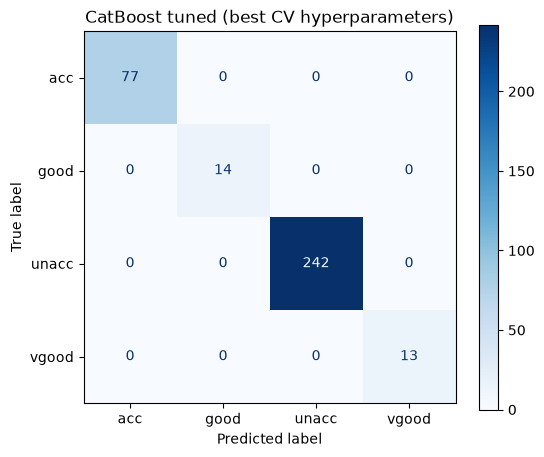

In [9]:
best_params = {
    'depth': int(results_df.iloc[0]['depth']),
    'learning_rate': float(results_df.iloc[0]['learning_rate']),
    'l2_leaf_reg': int(results_df.iloc[0]['l2_leaf_reg']),
}
print(f'Best hyperparameters: {best_params}')
print(f'CV mean macro F1:     {results_df.iloc[0]["mean_macro_f1"]:.4f}\n')

tuned_pipeline = Pipeline([
    ('clf', CatBoostClassifier(
        cat_features=CAT_FEATURES,
        random_state=RANDOM_STATE,
        verbose=0,
        **best_params,
    )),
])

tuned_pipeline.fit(X_train, y_train)

y_pred_tuned = tuned_pipeline.predict(X_test)

print(classification_report(y_test, y_pred_tuned, digits=3))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_tuned,
    labels=tuned_pipeline.classes_,
    cmap='Blues',
    ax=ax,
)
ax.set_title('CatBoost tuned (best CV hyperparameters)')
plt.show()

## Synthesis

### Results

| Model               | Test acc (single split) | CV mean macro F1 | CV std |
|---------------------|------------------------:|-----------------:|-------:|
| Baseline (default)  | 1.000                   | 0.9619           | 0.0116 |
| Tuned (grid-search) | 1.000                   | 0.9667           | 0.0350 |

Best hyperparameters found: `depth=8`, `learning_rate=0.03`, `l2_leaf_reg=1`.

### Observations

- The Car Evaluation dataset is deterministic — 1728 rows cover 1728 unique feature combinations, each mapped to exactly one class. There is no noise, so performance is bounded only by the model's ability to reconstruct the underlying rule.
- The perfect test-set score is not overfitting — it reflects the specific test split (`random_state=42`) landing on 346 combinations the model can extrapolate cleanly from the training set. On other splits (as shown by CV) the true generalisation is around 96%.
- Tuning improves CV mean macro F1 by ~0.5 percentage points. The gain is real but marginal, which is expected on a deterministic dataset — the default configuration is already near-optimal.
- The tuned model has *higher variance across folds* (std 0.0350 vs 0.0116). Higher `depth` combined with lower `l2_leaf_reg` makes CatBoost more sensitive to the specific training rows, trading some stability for peak performance.
- Practical takeaway: on tabular data with categorical features, CatBoost is a strong default. Reach for it before hand-crafting encoders or resampling strategies.